In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\USER\Downloads\india_cancer_patients_age_group.csv")
df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status,Age_Group
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,6/5/2024,3.5,Deceased,Senior
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,8/12/2023,34.0,Alive,Adult
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,9/9/2023,33.0,Alive,Adult
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,3/1/2024,27.3,Alive,Pediatric
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,5/17/2022,24.0,Deceased,Adult


In [2]:
df.info()
df['Status'].value_counts()
df['Cancer_Type'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  str    
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  str    
 3   State            100000 non-null  str    
 4   City             100000 non-null  str    
 5   Hospital_Name    100000 non-null  str    
 6   Cancer_Type      100000 non-null  str    
 7   Stage            100000 non-null  str    
 8   Treatment_Type   100000 non-null  str    
 9   Diagnosis_Date   100000 non-null  str    
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  str    
 12  Age_Group        100000 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 9.9 MB


Cancer_Type
Breast Cancer        28169
Oral Cancer          16259
Cervical Cancer      13881
Lung Cancer          12046
Colorectal Cancer     7935
Stomach Cancer        7923
Prostate Cancer       5809
Leukemia              4070
Ovarian Cancer        3908
Name: count, dtype: int64

In [9]:
total_patients = len(df)
pct_alive = (df['Status'] == 'Alive').mean() * 100
pct_deceased = (df['Status'] == 'Deceased').mean() * 100
avg_survival = df['Survival_Months'].mean()
most_common_cancer = df['Cancer_Type'].value_counts().idxmax()

print(f"Total Patients: {total_patients:,}")
print(f"% Alive: {pct_alive:.2f}%")
print(f"% Deceased: {pct_deceased:.2f}%")
print(f"Average Survival (Months): {avg_survival:.2f}")
print(f"Most Common Cancer Type: {most_common_cancer}")

Total Patients: 100,000
% Alive: 36.42%
% Deceased: 63.58%
Average Survival (Months): 20.33
Most Common Cancer Type: Breast Cancer


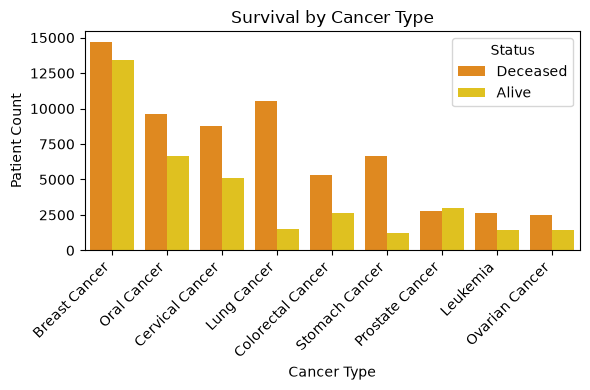

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Cancer_Type', hue='Status', 
              order=df['Cancer_Type'].value_counts().index,
              palette={'Alive':'gold', 'Deceased':'darkorange'})
plt.title('Survival by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Patient Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

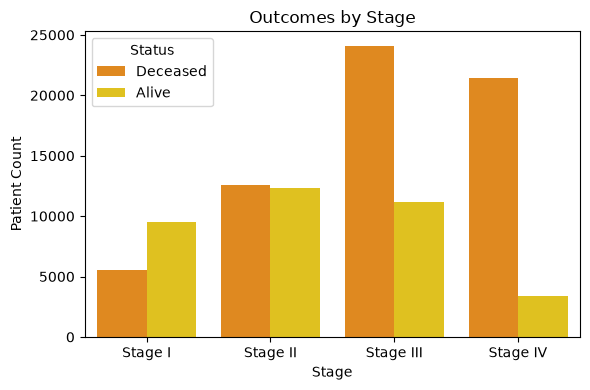

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Stage', hue='Status',
              order=['Stage I','Stage II','Stage III','Stage IV'],
              palette={'Alive':'gold', 'Deceased':'darkorange'})
plt.title('Outcomes by Stage')
plt.xlabel('Stage')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

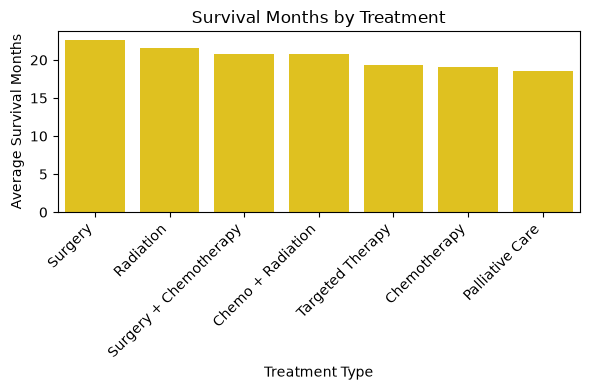

In [5]:
plt.figure(figsize=(6,4))
avg_survival = df.groupby('Treatment_Type')['Survival_Months'].mean().sort_values(ascending=False)
sns.barplot(x=avg_survival.index, y=avg_survival.values, color='gold')
plt.title('Survival Months by Treatment')
plt.xlabel('Treatment Type')
plt.ylabel('Average Survival Months')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

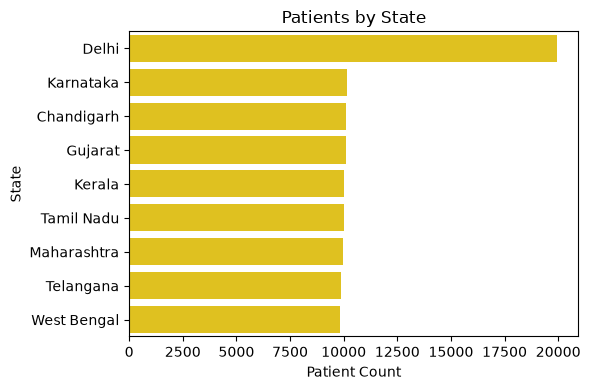

In [6]:
plt.figure(figsize=(6,4))
state_counts = df['State'].value_counts()
sns.barplot(x=state_counts.values, y=state_counts.index, color='gold')
plt.title('Patients by State')
plt.xlabel('Patient Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

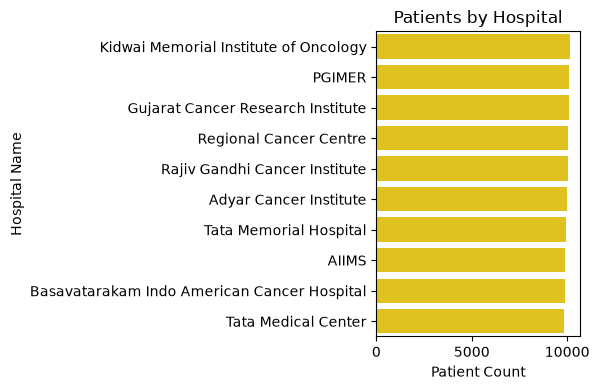

In [7]:
plt.figure(figsize=(6,4))
hospital_counts = df['Hospital_Name'].value_counts()
sns.barplot(x=hospital_counts.values, y=hospital_counts.index, color='gold')
plt.title('Patients by Hospital')
plt.xlabel('Patient Count')
plt.ylabel('Hospital Name')
plt.tight_layout()
plt.show()

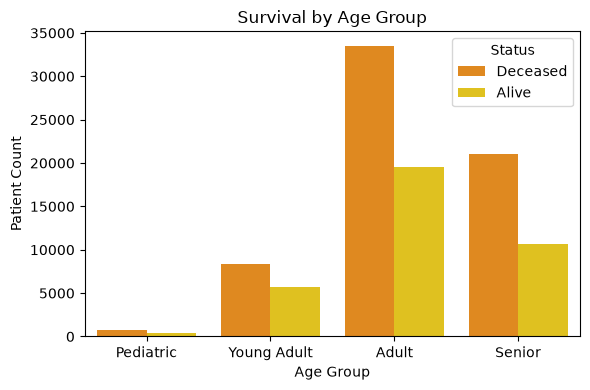

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Age_Group', hue='Status',
              order=['Pediatric','Young Adult','Adult','Senior'],
              palette={'Alive':'gold', 'Deceased':'darkorange'})
plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

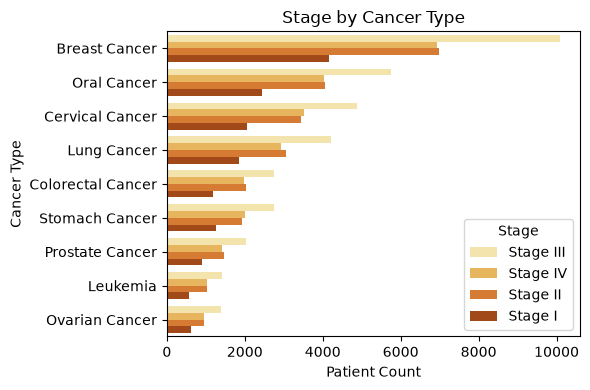

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, y='Cancer_Type', hue='Stage',
              order=df['Cancer_Type'].value_counts().index,
              palette='YlOrBr')
plt.title('Stage by Cancer Type')
plt.xlabel('Patient Count')
plt.ylabel('Cancer Type')
plt.tight_layout()
plt.show()